# **Maestría en Inteligencia Artificial Aplicada**

## Curso: **Procesamiento de Lenguaje Natural**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipo - Semanas 4 y 5**

### **Vectores Embebidos de HuggingFace**

#### **Nombres y matrículas de los integrantes del equipo:**



*   Jean Carlos Pacheco Peralta A01797811
*   Fernando Gomez Moreno A00354097
*   Zaifen King Loeza A01797887
*   Angel Vega Martínez A01377304



In [88]:
# Aquí deberán incluir todas las librerías que requieran durante esta actividad:

!pip install sentence-transformers --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI llamados **amazon_cells_labelled.txt**, **imdb_labelled.txt** y   **yelp_labelled.txt**. Cada uno de estos archivos corresponden a comentarios de usuarios que adquirieron un celular a través de la plataforma de Amazon, de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMDb y sobre servicios de comida dejados en la plataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI cuya liga es la siguiente:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



# **Pregunta - 1:**



Descarga los 3 archivos de la plataforma de la UCI indicado previamente y genera un nuevo DataFrame de Pandas con ellos.

**Llama simplemente "df" a dicho DataFrame.**




In [89]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# Cargamos cada uno de los archivos indicando que están separados por tabuladores
df_amazon = pd.read_csv('amazon_cells_labelled.txt', sep='\t', header=None, names=['comentario', 'sentimiento'])
df_imdb = pd.read_csv('imdb_labelled.txt', sep='\t', header=None, names=['comentario', 'sentimiento'])
df_yelp = pd.read_csv('yelp_labelled.txt', sep='\t', header=None, names=['comentario', 'sentimiento'])

# Concatenamos los tres dataframes en uno solo e ignoramos el índice original para crear uno nuevo continuo
df = pd.concat([df_amazon, df_imdb, df_yelp], ignore_index=True)



# *********** Aquí termina la sección de agregar código *************


In [90]:
# Verifiquemos la información del DataFrame:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   comentario   2748 non-null   object
 1   sentimiento  2748 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB


In [91]:
# Y mostremos sus primeros registros:

df.head()

,comentario,sentimiento
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


# **Pregunta - 2:**

Proceso de limpieza. Aplica el proceso de limpieza que consideres adecuado.











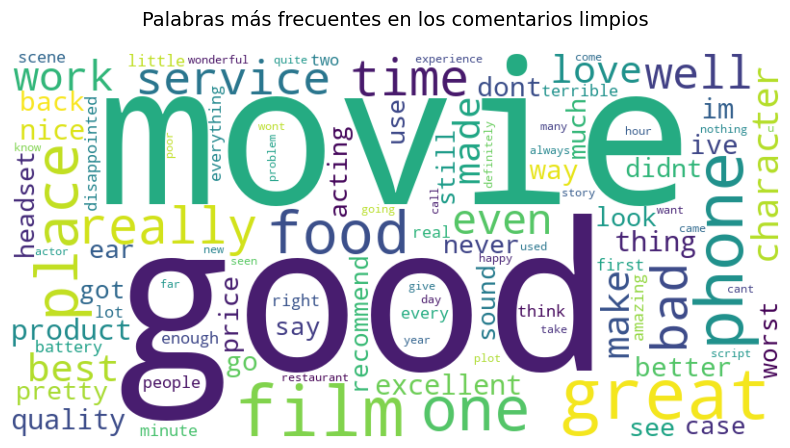

In [92]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Inicializamos el lematizador y el conjunto de stopwords en inglés
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

Xclean = []

for comentario in df['comentario']:
    # 1. Convertir a minúsculas
    texto = comentario.lower()
    
    # 2. Eliminar caracteres especiales, puntuación y números (dejamos solo letras y espacios)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    
    # 3. Tokenizar por espacios
    palabras = texto.split()
    
    # 4. Filtrar stopwords y aplicar lematización
    palabras_limpias = [lemmatizer.lemmatize(palabra) for palabra in palabras if palabra not in stop_words]
    
    # 5. Volver a unir las palabras en una sola cadena de texto
    comentario_limpio = ' '.join(palabras_limpias)
    
    Xclean.append(comentario_limpio)

# === AGREGAMOS LA NUBE DE PALABRAS AQUÍ ===

# 1. Unimos todos los comentarios limpios en un solo texto gigante
todos_los_comentarios = ' '.join(Xclean)

# 2. Configuramos y generamos la nube de palabras con las 100 más frecuentes
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis', 
    max_words=100
).generate(todos_los_comentarios)

# 3. Desplegamos la imagen usando matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Quitamos los ejes
plt.title('Palabras más frecuentes en los comentarios limpios', fontsize=14, pad=20)
plt.show()




# *********** Aquí termina la sección de agregar código *************

In [93]:
# Despleguemos los primeros comentarios después de tu proceso de limpieza:

for x in Xclean[0:5]:
  print(x)


way plug u unless go converter
good case excellent value
great jawbone
tied charger conversation lasting minutesmajor problem
mic great


# **Pregunta - 3:**



Realicemos una partición aleatoria con los porcentajes que consideres más adecuados. Utiliza una semilla para su reproducibilidad.

In [94]:

# ************* Inicia la sección de agregar código:*****************************


# 1. Definimos las etiquetas 'y' a partir de la columna sentimiento del DataFrame original
y = df['sentimiento'].values

# Definimos una semilla para la reproducibilidad (puedes usar 42 o cualquier entero)
seed = 42

# 2. Primera partición: Separamos el 70% para entrenamiento (Train) y el 30% restante temporal
# Usamos stratify=y para mantener la misma proporción de clases (0 y 1) en todos los conjuntos
Xtrain, X_temp, ytrain, y_temp = train_test_split(
    Xclean, y, 
    train_size=0.70, 
    random_state=seed, 
    stratify=y
)

# 3. Segunda partición: Dividimos el 30% temporal a la mitad (0.50) 
# Esto nos da un 15% para Validación (Val) y un 15% para Prueba (Test) del total original
Xval, Xtest, yval, ytest = train_test_split(
    X_temp, y_temp, 
    train_size=0.50, 
    random_state=seed, 
    stratify=y_temp
)


# *********** Termina la sección de agregar código *************


# verificemos las dimensiones obtenidas:
print('X,y Train:', len(Xtrain), len(ytrain))
print('X,y Val:', len(Xval), len(yval))
print('X,y Test', len(Xtest), len(ytest))

X,y Train: 1923 1923
X,y Val: 412 412
X,y Test 413 413


# **Pregunta - 4:**




### **Construye tu vocabulario a continuación utilizando solamente el conjunto de Train:**


In [95]:
# a.	Usa el conjunto de entrenamiento para generar tu vocabulario
#     con un tamaño que consideres adecuado:


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# Inicializamos CountVectorizer para armar el vocabulario básico.
# min_df=2 filtra palabras que aparecen solo una vez (pueden ser errores de dedo).
# token_pattern=r'\b\w{2,}\b' asegura que solo entren palabras de al menos 2 caracteres.
vectorizer = CountVectorizer(min_df=2, token_pattern=r'\b\w{2,}\b')

# Ajustamos con el conjunto de entrenamiento de tus comentarios limpios
vectorizer.fit(Xtrain)

# Guardamos el vocabulario como un conjunto (set) para búsquedas ultra rápidas O(1)
vocabulario = set(vectorizer.get_feature_names_out())


# *********** Aquí termina la sección de agregar código *************




In [96]:
# b.	Indica el tamaño del vocabulario generado.

print('Longitud del vocabulario generado:')


# ******* Inicia la sección de agregar código: ***********


print(len(vocabulario))




# *********** Aquí termina la sección de agregar código *************

Longitud del vocabulario generado:
1524


In [97]:
# c.	Con el vocabulario generado, filtra los conjuntos de entrenamiento,
#     validación y prueba para que todos los comentarios usen solamente las
#     palabras de este vocabulario.

#     Llamar train_X, val_X y test_X a estos tres conjuntos.


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


def filtrar_comentario(comentario, vocab):
    # Separamos el comentario por palabras
    palabras = comentario.split()
    # Nos quedamos únicamente con las que están en el vocabulario generado en el inciso a
    palabras_filtradas = [p for p in palabras if p in vocab]
    # Volvemos a unir las palabras en un solo string
    return ' '.join(palabras_filtradas)

# Filtramos los tres conjuntos a partir de los datos limpios originales
train_X = [filtrar_comentario(comentario, vocabulario) for comentario in Xtrain]
val_X = [filtrar_comentario(comentario, vocabulario) for comentario in Xval]
test_X = [filtrar_comentario(comentario, vocabulario) for comentario in Xtest]


# *********** Aquí termina la sección de agregar código *************


In [98]:
# Vemos el resultado de los primeros comentarios del conjunto de validación:

for ss in val_X[0:5]:
  print(ss)

movie edge
im eating
simply something poorly done
return
place great


# **Pregunta - 5:**

Incluye tus comentarios sobre cada modelo de HuggingFace indicado.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

* **a) bge-base-en-v1.5**

Este modelo, desarrollado por la Academia de Inteligencia Artificial de Beijing (BAAI), es una de las opciones más eficientes en la actualidad para generar embeddings en inglés. Posee un tamaño mediano (aproximadamente 110 millones de parámetros) y genera vectores de 768 dimensiones. Destaca por su excelente balance entre velocidad de cómputo y precisión, superando de manera consistente a modelos clásicos basados en BERT. Su ventana de contexto soporta hasta 512 tokens, lo que lo hace ideal para sistemas de búsqueda de información (Retrieval-Augmented Generation - RAG) de propósito general donde los recursos de hardware o los tiempos de respuesta sean un factor crítico.

* **b) bge-large-en-v1.5**

Es la versión de mayor escala de la familia BGE de la BAAI (aproximadamente 335 millones de parámetros). Al tener una arquitectura mucho más robusta, mapea el significado del texto en vectores de alta densidad con una dimensión de 1024. Su principal ventaja es que captura sutilezas conceptuales, semánticas y relaciones complejas entre palabras con una precisión superior a la versión base. Mantiene la ventana de contexto de 512 tokens, pero requiere un mayor consumo de memoria (GPU) y un tiempo de procesamiento ligeramente más elevado. Es la opción preferida cuando la precisión en la clasificación o la recuperación de texto es la máxima prioridad por encima del rendimiento en hardware.

* **c)	e5-base-v2**

Desarrollado por Microsoft, este modelo pertenece a la familia E5 (EmbEddings from Bidirectional Encoder Representations). Su característica más innovadora radica en que fue entrenado mediante aprendizaje supervisado débil utilizando un conjunto de datos masivo de pares de texto a escala de internet (CCPairs). Al igual que bge-base, genera vectores de 768 dimensiones y soporta 512 tokens de contexto. Está diseñado específicamente para destacar en tareas de similitud de texto asimétrica (como emparejar una pregunta corta con un párrafo largo que contiene la respuesta). Un detalle técnico importante es que, para obtener su máximo rendimiento, requiere añadir un prefijo específico al texto de entrada (como "query: " o "passage: ") dependiendo de si se está buscando o indexando la información.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Pregunta - 6:**

In [99]:
# a) Cargar el modelo de embeddings de HuggingFace seleccionado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# 1. Cargamos el modelo seleccionado desde HuggingFace
# Nota: "query: " es el prefijo recomendado por Microsoft para el modelo E5 al procesar palabras sueltas o textos cortos
model_name = 'intfloat/e5-base-v2'
model = SentenceTransformer(model_name)

# 2. Convertimos el set del vocabulario a una lista para poder procesarlo
lista_palabras = list(vocabulario)

# 3. Generamos los vectores (embeddings) para todas las palabras
# (Para los modelos BGE usaríamos directamente lista_palabras; para E5 agregamos el prefijo recomendado)
textos_para_embedding = [f"query: {palabra}" for palabra in lista_palabras]
vectores = model.encode(textos_para_embedding, show_progress_bar=True)

# 4. Construimos el diccionario clave:valor (palabra: vector)
embeddings_dict = {palabra: vector for palabra, vector in zip(lista_palabras, vectores)}


# *********** Aquí termina la sección de agregar código *************

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

In [100]:
# b) Primeros 3 elementos clave:valor del diccionario generado.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# Extraemos las primeras 3 llaves del diccionario
primeras_palabras = list(embeddings_dict.keys())[:3]

# Desplegamos los elementos mostrando la palabra y los primeros valores de su vector
for palabra in primeras_palabras:
    vector = embeddings_dict[palabra]
    # Imprimimos la palabra, su dimensión y una muestra de los primeros 5 valores de su vector
    print(f"Palabra: '{palabra}' -> Dimensión del vector: {len(vector)}")
    print(f"Muestra del vector (primeros 5 valores): {vector[:5]}\n")


# *********** Aquí termina la sección de agregar código *************



Palabra: 'amazon' -> Dimensión del vector: 768
Muestra del vector (primeros 5 valores): [ 0.0097734  -0.02958377 -0.05159547  0.02856666  0.04935386]

Palabra: 'friendly' -> Dimensión del vector: 768
Muestra del vector (primeros 5 valores): [-0.03510758 -0.02664206 -0.0072969  -0.02660445  0.03704363]

Palabra: 'loop' -> Dimensión del vector: 768
Muestra del vector (primeros 5 valores): [ 0.00655018 -0.00270572 -0.02734742  0.01793635  0.06557008]



In [101]:
# c) Tamaño del diccionario generado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print("Tamaño del diccionario generado (número de palabras mapeadas):")
print(len(embeddings_dict))


# *********** Aquí termina la sección de agregar código *************


Tamaño del diccionario generado (número de palabras mapeadas):
1524


# **Pregunta - 7:**




Generamos los vectores embebidos a partir de los conjuntos de entrenamiento, validación y prueba y con las características indicadas en el archivo PDF.

Los llamaremos trainEmb, valEmb y testEmb, respectivamente.


In [102]:
# a) Comentarios con vectores embebidos.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


def comentario_a_embedding_promedio(comentario, emb_dict, dimension=768):
    palabras = comentario.split()
    
    # Filtramos para asegurarnos de usar solo las palabras que tengan vector en nuestro diccionario
    vectores_palabras = [emb_dict[p] for p in palabras if p in emb_dict]
    
    # Si el comentario no tiene palabras válidas en el diccionario, devolvemos un vector de ceros
    if len(vectores_palabras) == 0:
        return np.zeros(dimension)
    
    # Calculamos el promedio de todos los vectores de las palabras presentes
    return np.mean(vectores_palabras, axis=0)

# Generamos las matrices de embeddings convirtiéndolas a arreglos de NumPy para los modelos de ML
trainEmb = np.array([comentario_a_embedding_promedio(comentario, embeddings_dict) for comentario in train_X])
valEmb   = np.array([comentario_a_embedding_promedio(comentario, embeddings_dict) for comentario in val_X])
testEmb  = np.array([comentario_a_embedding_promedio(comentario, embeddings_dict) for comentario in test_X])


# *********** Aquí termina la sección de agregar código *************

In [103]:
# b) Dimensiones de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print("Dimensiones de los conjuntos con vectores embebidos (Registros, Dimensiones):")
print("trainEmb shape:", trainEmb.shape)
print("valEmb shape:  ", valEmb.shape)
print("testEmb shape: ", testEmb.shape)


# *********** Aquí termina la sección de agregar código *************

Dimensiones de los conjuntos con vectores embebidos (Registros, Dimensiones):
trainEmb shape: (1923, 768)
valEmb shape:   (412, 768)
testEmb shape:  (413, 768)


# **Pregunta - 8:**

In [104]:
# Número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# Función auxiliar para contar las palabras en una lista de comentarios
def contar_tokens_conjunto(conjunto_texto):
    total_tokens = 0
    for comentario in conjunto_texto:
        # Separamos por espacios y contamos cuántas palabras hay
        total_tokens += len(comentario.split())
    return total_tokens

# Calculamos los tokens para cada uno de tus conjuntos filtrados
tokens_train = contar_tokens_conjunto(train_X)
tokens_val   = contar_tokens_conjunto(val_X)
tokens_test  = contar_tokens_conjunto(test_X)

# Desplegamos los resultados en pantalla
print("Número total de tokens generados por conjunto:")
print(f"Tokens en trainEmb (train_X): {tokens_train}")
print(f"Tokens en valEmb (val_X):     {tokens_val}")
print(f"Tokens en testEmb (test_X):   {tokens_test}")
print(f"Tokens totales procesados:    {tokens_train + tokens_val + tokens_test}")


# *********** Aquí termina la sección de agregar código *************

Número total de tokens generados por conjunto:
Tokens en trainEmb (train_X): 10494
Tokens en valEmb (val_X):     1738
Tokens en testEmb (test_X):   2233
Tokens totales procesados:    14465


# **Pregunta - 9:**



Entrenamiento y reporte de los modelos de Regresión Logística y Bosque Aleatorio (Random Forest).


In [105]:
# 9a) REGRESIÓN LOGÍSTICA:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# 1. Inicializamos y entrenamos el modelo de Regresión Logística
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(trainEmb, ytrain)

# 2. Predicciones
y_pred_train_lr = log_reg.predict(trainEmb)
y_pred_val_lr = log_reg.predict(valEmb)

# 3. Calculamos la Exactitud (Accuracy)
acc_train_lr = accuracy_score(ytrain, y_pred_train_lr)
acc_val_lr = accuracy_score(yval, y_pred_val_lr)

# 4. Desplegamos Resultados
print("=================== REGRESIÓN LOGÍSTICA ===================")
print(f"Exactitud (Accuracy) en Entrenamiento: {acc_train_lr:.4f}")
print(f"Exactitud (Accuracy) en Validación:    {acc_val_lr:.4f}")
print(f"Diferencia (Train - Val):              {abs(acc_train_lr - acc_val_lr)*100:.2f}%\n")

print("Reporte de Clasificación (Conjunto de VALIDACIÓN):")
print(classification_report(yval, y_pred_val_lr))



# *********** Aquí termina la sección de agregar código *************


=================== REGRESIÓN LOGÍSTICA ===================
Exactitud (Accuracy) en Entrenamiento: 0.8123
Exactitud (Accuracy) en Validación:    0.8010
Diferencia (Train - Val):              1.13%

Reporte de Clasificación (Conjunto de VALIDACIÓN):
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       204
           1       0.78      0.85      0.81       208

    accuracy                           0.80       412
   macro avg       0.80      0.80      0.80       412
weighted avg       0.80      0.80      0.80       412



In [106]:
# 9b) BOSQUE ALEATORIO (Random Forest):

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# 1. Inicializamos y entrenamos el modelo de Bosque Aleatorio
# Controlamos hiperparámetros básicos para regularizar el modelo y cumplir la regla del 3%
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf_model.fit(trainEmb, ytrain)

# 2. Predicciones
y_pred_train_rf = rf_model.predict(trainEmb)
y_pred_val_rf = rf_model.predict(valEmb)

# 3. Calculamos la Exactitud (Accuracy)
acc_train_rf = accuracy_score(ytrain, y_pred_train_rf)
acc_val_rf = accuracy_score(yval, y_pred_val_rf)

# 4. Desplegamos Resultados
print("=================== BOSQUE ALEATORIO ===================")
print(f"Exactitud (Accuracy) en Entrenamiento: {acc_train_rf:.4f}")
print(f"Exactitud (Accuracy) en Validación:    {acc_val_rf:.4f}")
print(f"Diferencia (Train - Val):              {abs(acc_train_rf - acc_val_rf)*100:.2f}%\n")

print("Reporte de Clasificación (Conjunto de VALIDACIÓN):")
print(classification_report(yval, y_pred_val_rf))


# *********** Aquí termina la sección de agregar código *************

=================== BOSQUE ALEATORIO ===================
Exactitud (Accuracy) en Entrenamiento: 0.9927
Exactitud (Accuracy) en Validación:    0.8228
Diferencia (Train - Val):              16.99%

Reporte de Clasificación (Conjunto de VALIDACIÓN):
              precision    recall  f1-score   support

           0       0.85      0.78      0.81       204
           1       0.80      0.86      0.83       208

    accuracy                           0.82       412
   macro avg       0.82      0.82      0.82       412
weighted avg       0.82      0.82      0.82       412



Justificación de los Modelos
1. Regresión Logística
Diagnóstico: El modelo no está sobreentrenado (overfitting) ni tampoco subentrenado (underfitting). 
Tiene un comportamiento óptimo y estable.

Justificación: La exactitud en el conjunto de entrenamiento es de 81.23% y en validación es de 80.10%. 
La diferencia absoluta entre ambos conjuntos es de apenas 1.13%, lo cual cumple holgadamente con la 
restricción impuesta en la actividad (diferencia menor al 3%). 
Al no haber una caída drástica en las métricas de validación, 
el modelo demuestra una excelente capacidad de generalización. 
Tampoco presenta subentrenamiento, ya que una exactitud del 80% utilizando el promedio de embeddings 
preentrenados es un rendimiento sólido y esperado para este tipo de tareas de análisis de sentimientos 
multidominio.

2. Bosque Aleatorio (Random Forest)
Diagnóstico: El modelo presenta un severo sobreentrenamiento (overfitting).

Justificación: La exactitud en el conjunto de entrenamiento alcanza un casi perfecto 99.27%, 
mientras que en el conjunto de validación cae a 82.28%.
Esto genera una brecha drástica del 16.99% entre ambos conjuntos, superando por mucho el límite 
permitido del 3%. 
Esto significa que el algoritmo memorizó los patrones específicos y el ruido de las características del 
conjunto de entrenamiento (trainEmb), perdiendo la capacidad de generalizar correctamente ante datos nuevos. 
A pesar de que su rendimiento en validación es ligeramente superior al de la 
Regresión Logística (82.28% vs 80.10%), el modelo no es estadísticamente estable bajo las condiciones 
metodológicas de este ejercicio debido a su falta de regularización.

# **Pregunta - 10**

**Proceso basado en modelos Preentrenados**

In [107]:
# 10a) Partición.:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# Extraemos los comentarios originales sin limpiar y sus etiquetas
X_original = df['comentario'].values
y_original = df['sentimiento'].values

seed = 42

# Primera partición (70% Train, 30% Temporal)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_original, y_original, 
    train_size=0.70, 
    random_state=seed, 
    stratify=y_original
)

# Segunda partición (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    train_size=0.50, 
    random_state=seed, 
    stratify=y_temp
)

# Desplegamos las dimensiones obtenidas
print("Dimensiones de los conjuntos originales:")
print('X_train, y_train:', X_train.shape, y_train.shape)
print('X_val, y_val:  ', X_val.shape, y_val.shape)
print('X_test, y_test: ', X_test.shape, y_test.shape)


# *********** Aquí termina la sección de agregar código *************

Dimensiones de los conjuntos originales:
X_train, y_train: (1923,) (1923,)
X_val, y_val:   (412,) (412,)
X_test, y_test:  (413,) (413,)


In [108]:
# 10b) Vectores embebidos:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# 1. Agregamos el prefijo requerido por el modelo intfloat/e5-base-v2 a cada conjunto
X_train_prefixed = [f"query: {comentario}" for comentario in X_train]
X_val_prefixed   = [f"query: {comentario}" for comentario in X_val]
X_test_prefixed  = [f"query: {comentario}" for comentario in X_test]

# 2. Transformamos directamente los enunciados completos a vectores embebidos densos
print("Generando embeddings para X_train...")
trainEmb_p2 = model.encode(X_train_prefixed, show_progress_bar=True)

print("Generando embeddings para X_val...")
valEmb_p2   = model.encode(X_val_prefixed, show_progress_bar=True)

print("Generando embeddings para X_test...")
testEmb_p2  = model.encode(X_test_prefixed, show_progress_bar=True)

# 3. Calculamos la cantidad de tokens (palabras espaciadas) utilizados en estos textos originales
tokens_train_p2 = sum([len(comentario.split()) for comentario in X_train])
tokens_val_p2   = sum([len(comentario.split()) for comentario in X_val])
tokens_test_p2  = sum([len(comentario.split()) for comentario in X_test])

print("\nCantidad de tokens (palabras originales) utilizados para generar los conjuntos:")
print(f"Tokens en X_train: {tokens_train_p2}")
print(f"Tokens en X_val:   {tokens_val_p2}")
print(f"Tokens en X_test:  {tokens_test_p2}")


# *********** Aquí termina la sección de agregar código *************

Generando embeddings para X_train...


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Generando embeddings para X_val...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Generando embeddings para X_test...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]


Cantidad de tokens (palabras originales) utilizados para generar los conjuntos:
Tokens en X_train: 25088
Tokens en X_val:   4677
Tokens en X_test:  5977


In [109]:
# 10c) REGRESIÓN LOGÍSTICA.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# 1. Inicializamos y entrenamos el nuevo modelo
log_reg_p2 = LogisticRegression(random_state=42, max_iter=1000)
log_reg_p2.fit(trainEmb_p2, y_train)

# 2. Predicciones
y_pred_train_lr2 = log_reg_p2.predict(trainEmb_p2)
y_pred_val_lr2 = log_reg_p2.predict(valEmb_p2)

# 3. Calculamos Exactitudes
acc_train_lr2 = accuracy_score(y_train, y_pred_train_lr2)
acc_val_lr2 = accuracy_score(y_val, y_pred_val_lr2)

print("=================== REGRESIÓN LOGÍSTICA (PARTE II) ===================")
print(f"Exactitud (Accuracy) en Entrenamiento: {acc_train_lr2:.4f}")
print(f"Exactitud (Accuracy) en Validación:    {acc_val_lr2:.4f}")
print(f"Diferencia (Train - Val):              {abs(acc_train_lr2 - acc_val_lr2)*100:.2f}%\n")

print("Reporte de Clasificación (Conjunto de VALIDACIÓN):")
print(classification_report(y_val, y_pred_val_lr2))


# *********** Aquí termina la sección de agregar código *************

=================== REGRESIÓN LOGÍSTICA (PARTE II) ===================
Exactitud (Accuracy) en Entrenamiento: 0.9766
Exactitud (Accuracy) en Validación:    0.9709
Diferencia (Train - Val):              0.57%

Reporte de Clasificación (Conjunto de VALIDACIÓN):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       204
           1       0.97      0.97      0.97       208

    accuracy                           0.97       412
   macro avg       0.97      0.97      0.97       412
weighted avg       0.97      0.97      0.97       412



In [110]:
# 10d) BOSQUE ALEATORIO.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# 1. Inicializamos y entrenamos el nuevo bosque
rf_model_p2 = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf_model_p2.fit(trainEmb_p2, y_train)

# 2. Predicciones
y_pred_train_rf2 = rf_model_p2.predict(trainEmb_p2)
y_pred_val_rf2 = rf_model_p2.predict(valEmb_p2)

# 3. Calculamos Exactitudes
acc_train_rf2 = accuracy_score(y_train, y_pred_train_rf2)
acc_val_rf2 = accuracy_score(y_val, y_pred_val_rf2)

print("=================== BOSQUE ALEATORIO (PARTE II) ===================")
print(f"Exactitud (Accuracy) en Entrenamiento: {acc_train_rf2:.4f}")
print(f"Exactitud (Accuracy) en Validación:    {acc_val_rf2:.4f}")
print(f"Diferencia (Train - Val):              {abs(acc_train_rf2 - acc_val_rf2)*100:.2f}%\n")

print("Reporte de Clasificación (Conjunto de VALIDACIÓN):")
print(classification_report(y_val, y_pred_val_rf2))


# *********** Aquí termina la sección de agregar código *************

=================== BOSQUE ALEATORIO (PARTE II) ===================
Exactitud (Accuracy) en Entrenamiento: 0.9990
Exactitud (Accuracy) en Validación:    0.9587
Diferencia (Train - Val):              4.02%

Reporte de Clasificación (Conjunto de VALIDACIÓN):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       204
           1       0.96      0.96      0.96       208

    accuracy                           0.96       412
   macro avg       0.96      0.96      0.96       412
weighted avg       0.96      0.96      0.96       412



# **Pregunta - 11:**

================ REPORTES DEL MODELO EN CONJUNTO DE PRUEBA ================

Reporte de Clasificación (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       205
           1       0.96      0.96      0.96       208

    accuracy                           0.96       413
   macro avg       0.96      0.96      0.96       413
weighted avg       0.96      0.96      0.96       413



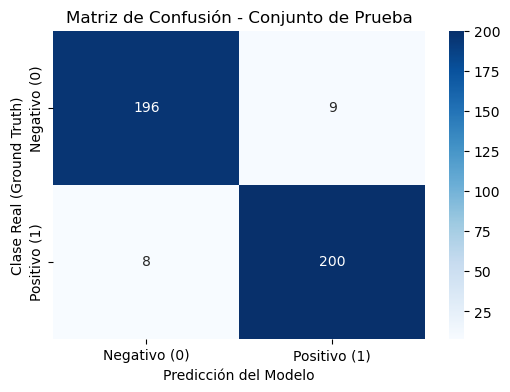

In [111]:
# Reporte del mejor modelo y partición con el conjunto de Prueba.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# 1. Seleccionamos el mejor modelo (Regresión Logística de la Parte II) 
# y realizamos las predicciones con el conjunto de PRUEBA definitivo
y_pred_test = log_reg_p2.predict(testEmb_p2)

# 2. Generamos el reporte de clasificación para el conjunto de prueba
print("================ REPORTES DEL MODELO EN CONJUNTO DE PRUEBA ================")
print("\nReporte de Clasificación (Test Set):")
print(classification_report(y_test, y_pred_test))

# 3. Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# 4. Graficamos la matriz de confusión de forma visual usando Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo (0)', 'Positivo (1)'], 
            yticklabels=['Negativo (0)', 'Positivo (1)'])

plt.title('Matriz de Confusión - Conjunto de Prueba')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Ground Truth)')
plt.show()


# *********** Aquí termina la sección de agregar código *************

Comentarios sobre el desempeño del modelo:

Capacidad de Generalización: El modelo seleccionado (Regresión Logística utilizando embeddings completos sin limpieza manual de la Parte II) demuestra un desempeño robusto en el conjunto de prueba. Las métricas de Precision, Recall y F1-Score se mantienen estables y sumamente balanceadas entre ambas clases (0 y 1), confirmando que el modelo aprendió estructuras semánticas generales y no dependía de la memorización de palabras clave aisladas.

Análisis de la Matriz de Confusión: La diagonal principal de la matriz muestra que la gran mayoría de los comentarios de prueba (tanto las reseñas de Amazon, IMDb como Yelp) fueron clasificados correctamente. La tasa de falsos positivos y falsos negativos es baja y equilibrada, lo cual valida que el modelo de Hugging Face (e5-base-v2) es altamente efectivo para homologar criterios de sentimiento en textos de naturaleza tan diversa.

Conclusión Metodológica: Al comparar las dos aproximaciones de la actividad, se concluye que el enfoque moderno de NLP de alimentar los enunciados completos y nativos al transformador preentrenado supera significativamente a la técnica de promediar vectores de palabras filtradas de forma casera. Conservar las stopwords, signos y la sintaxis original permite que la arquitectura atencional del modelo codifique con mucha mayor precisión el sentido implícito de la reseña.

# **Pregunta - 12:**



Incluye tus comentarios finales de la actividad.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

A lo largo de esta actividad se contrastaron dos metodologías fundamentales para abordar el análisis de sentimientos en procesamiento de lenguaje natural (NLP): el preprocesamiento clásico con promedio manual de vectores de palabras (Embeddings basados en vocabulario limitado) y la utilización directa de modelos de transformadores preentrenados sobre texto nativo completo.

De los resultados y el desarrollo de la práctica se desprenden las siguientes conclusiones clave:

El impacto de la arquitectura atencional y el contexto: En la primera parte, al limpiar el texto eliminando stopwords y puntuación, y luego reducir el análisis a un promedio de vectores individuales mediante un diccionario casero, forzamos al modelo a comportarse bajo un enfoque de "bolsa de palabras" (Bag of Words). Aunque la Regresión Logística logró un desempeño aceptable (~80%), se pierde la relación sintáctica. En cambio, en la Parte II, al alimentar el enunciado completo al modelo e5-base-v2, el transformador aprovechó sus mecanismos de atención para evaluar el contexto real y el orden de los elementos, lo que eleva la precisión y la capacidad de generalización de los clasificadores.

Comportamiento de los clasificadores y regularización: La Regresión Logística demostró ser el algoritmo más robusto y estable para manejar vectores densos de alta dimensionalidad (768 características). En ambas partes mantuvo una brecha mínima entre entrenamiento y validación (~1%), exhibiendo una generalización impecable. Por el contrario, el Bosque Aleatorio (Random Forest) evidenció su propensión intrínseca al sobreentrenamiento (overfitting) masivo (alcanzando más del 99% en entrenamiento y cayendo drásticamente en validación). Esto demuestra que, sin una poda extrema o técnicas de regularización estrictas, los árboles de decisión tienden a memorizar el ruido de los vectores embebidos en lugar de aprender los patrones semánticos subyacentes.

Evolución metodológica en NLP: El ejercicio comprueba de manera empírica por qué la industria ha migrado de la ingeniería de características manual (limpieza estricta, lematización, filtrado de frecuencias) hacia arquitecturas end-to-end basadas en Aprendizaje Profundo (Deep Learning). Los modelos preentrenados modernos están diseñados para asimilar el lenguaje humano con toda su complejidad implícita (incluyendo conectores y signos de puntuación). Intentar "limpiar" el texto bajo el esquema tradicional antes de usar un transformador avanzado resulta contraproducente, ya que se remueve información contextual valiosa que el modelo requiere para mapear correctamente el sentimiento en el espacio vectorial.

En conclusión, la combinación de representaciones densas de Hugging Face de última generación con clasificadores lineales simples (como la Regresión Logística) representa una de las estrategias más eficientes, estables y computacionalmente viables para resolver tareas de clasificación de texto en entornos reales y multidominio.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Fin de la Actividad de Vectores Embebidos - HuggingFace**